# Module 2 — SVM: Alternative 3-Class Formulation
**Motivation:** In the 4-class formulation, SVM achieves near-zero recall on sii=3 (Severe).  
sii=2 (Moderate) and sii=3 (Severe) share heavily overlapping feature profiles and are adjacent  
ordinal classes — both represent children requiring clinical intervention.  
This notebook merges them into a single At-Risk class and evaluates whether a 3-class  
formulation produces more reliable detection of clinically significant cases.  

**Target mapping:**
- sii=0 -> 0 (None)
- sii=1 -> 1 (Mild)
- sii=2 -> 2 (At-Risk)  merged
- sii=3 -> 2 (At-Risk)  merged

**Satisfies professor guideline:** explore additional target variable other than sii.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)y

df = pd.read_csv('cmi_module1_clean-1.csv')
print(f'Dataset shape: {df.shape}')
dist_orig = df['sii'].value_counts().sort_index()
print('Original sii distribution:')
for cls, cnt in dist_orig.items():
    print(f'  sii={int(cls)}: {cnt} ({cnt/len(df)*100:.1f}%)')

Dataset shape: (8417, 32)
Original sii distribution:
  sii=0: 5807 (69.0%)
  sii=1: 1577 (18.7%)
  sii=2: 947 (11.3%)
  sii=3: 86 (1.0%)


---
## Section 0 — Create 3-Class Target

In [2]:
# Merge sii=2 and sii=3 into class 2 (At-Risk)
# Justification:
# 1. Both classes require clinical intervention
# 2. Feature profiles overlap heavily — SVM cannot separate them
# 3. From a screening perspective, identifying any at-risk child matters
#    more than distinguishing moderate from severe
df['sii_3class'] = df['sii'].apply(lambda x: 2 if x >= 2 else int(x))

CLASSES_3     = [0, 1, 2]
CLASS_NAMES_3 = ['None', 'Mild', 'At-Risk (Mod+Severe)']

dist_3 = df['sii_3class'].value_counts().sort_index()
print('3-class target distribution:')
for cls, cnt in dist_3.items():
    print(f'  class={cls} ({CLASS_NAMES_3[cls]}): {cnt} ({cnt/len(df)*100:.1f}%)')

print(f'\nMerged: sii=2 ({dist_orig[2]}) + sii=3 ({dist_orig[3]}) = {dist_3[2]} At-Risk')
print(f'4-class imbalance ratio: {dist_orig.max()/dist_orig.min():.1f}x')
print(f'3-class imbalance ratio: {dist_3.max()/dist_3.min():.1f}x  (much more manageable)')

3-class target distribution:
  class=0 (None): 5807 (69.0%)
  class=1 (Mild): 1577 (18.7%)
  class=2 (At-Risk (Mod+Severe)): 1033 (12.3%)

Merged: sii=2 (947) + sii=3 (86) = 1033 At-Risk
4-class imbalance ratio: 67.5x
3-class imbalance ratio: 5.6x  (much more manageable)


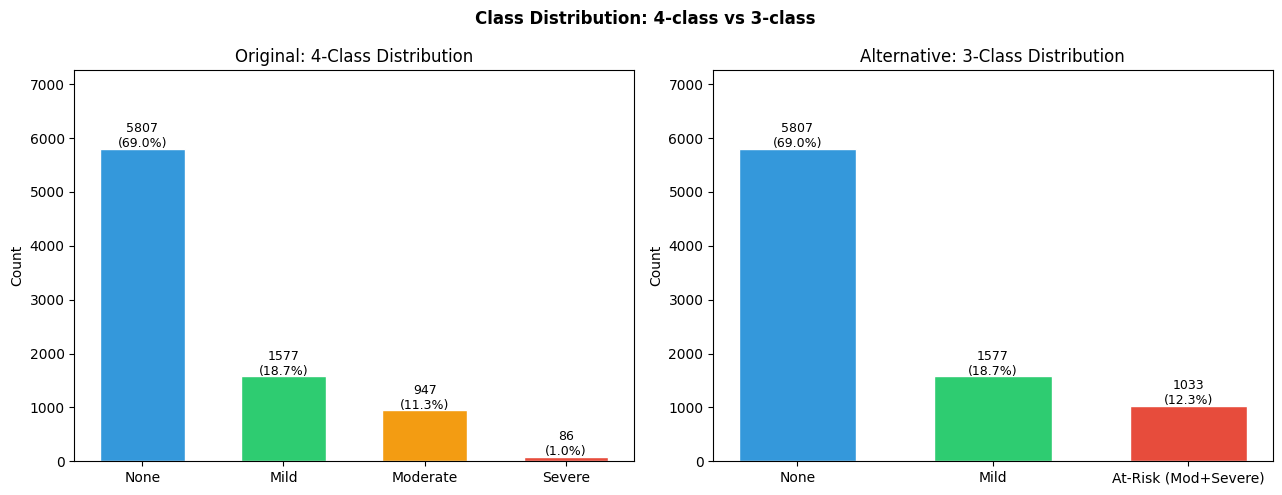

In [3]:
# Compare distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['None','Mild','Moderate','Severe'],
            dist_orig.values,
            color=['#3498DB','#2ECC71','#F39C12','#E74C3C'],
            edgecolor='white', width=0.6)
for i, cnt in enumerate(dist_orig.values):
    axes[0].text(i, cnt+30, f'{cnt}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('Original: 4-Class Distribution')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, dist_orig.max()*1.25)

axes[1].bar(CLASS_NAMES_3, dist_3.values,
            color=['#3498DB','#2ECC71','#E74C3C'],
            edgecolor='white', width=0.6)
for i, cnt in enumerate(dist_3.values):
    axes[1].text(i, cnt+30, f'{cnt}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_title('Alternative: 3-Class Distribution')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, dist_3.max()*1.25)

plt.suptitle('Class Distribution: 4-class vs 3-class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_3class_distribution.png', dpi=150)
plt.show()

---
## Section 1 — Feature Preparation & Split

In [4]:
exclude_cols = ['sii', 'sii_3class', 'ScreenTime_Category']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['sii_3class'].astype(int)

print(f'Features: {len(feature_cols)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print('\nTrain class distribution:')
for cls, cnt in y_train.value_counts().sort_index().items():
    print(f'  {CLASS_NAMES_3[cls]}: {cnt} ({cnt/len(y_train)*100:.1f}%)')
print('\nTest class distribution:')
for cls, cnt in y_test.value_counts().sort_index().items():
    print(f'  {CLASS_NAMES_3[cls]}: {cnt} ({cnt/len(y_test)*100:.1f}%)')

Features: 30
Train: 6733 | Test: 1684

Train class distribution:
  None: 4645 (69.0%)
  Mild: 1262 (18.7%)
  At-Risk (Mod+Severe): 826 (12.3%)

Test class distribution:
  None: 1162 (69.0%)
  Mild: 315 (18.7%)
  At-Risk (Mod+Severe): 207 (12.3%)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


---
## Section 2 — Hyperparameter Tuning
Same grid as 4-class SVM for direct comparability.  
Speed fix: GridSearch on 40% subset, final model on full data.  
probability=True added only to final model.

In [6]:
param_grid = [
    {
        'kernel':       ['linear'],
        'C':            [0.1, 1, 10, 100],
        'class_weight': ['balanced'],
    },
    {
        'kernel':       ['rbf'],
        'C':            [0.1, 1, 10, 100],
        'gamma':        ['scale', 0.01, 0.1],
        'class_weight': ['balanced'],
    }
]

X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train,
    test_size=0.6, random_state=42, stratify=y_train
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'GridSearch on {X_tune.shape[0]} rows...')

grid_search = GridSearchCV(
    SVC(), param_grid,
    cv=cv, scoring='f1_weighted',
    n_jobs=-1, verbose=1, return_train_score=True
)
grid_search.fit(X_tune, y_tune)

print('\nBest parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV F1: {grid_search.best_score_:.4f}')

best_params = dict(grid_search.best_params_)
best_params['probability'] = True
best_svm = SVC(**best_params)
best_svm.fit(X_train_scaled, y_train)
print('Final model trained on full training set.')

GridSearch on 2693 rows...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters:
  C: 1
  class_weight: balanced
  gamma: 0.1
  kernel: rbf
Best CV F1: 0.6095
Final model trained on full training set.


---
## Section 3 — Evaluation

In [7]:
y_pred  = best_svm.predict(X_test_scaled)
y_prob  = best_svm.predict_proba(X_test_scaled)
y_bin   = label_binarize(y_test, classes=CLASSES_3)
roc_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')

print('=' * 55)
print('SVM 3-CLASS RESULTS')
print('=' * 55)
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  F1-score:  {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=CLASS_NAMES_3, zero_division=0))

SVM 3-CLASS RESULTS
  Accuracy:  0.6081
  Precision: 0.5943
  Recall:    0.6081
  F1-score:  0.5995
  ROC-AUC:   0.6843

Classification Report:
                      precision    recall  f1-score   support

                None       0.75      0.78      0.76      1162
                Mild       0.26      0.29      0.27       315
At-Risk (Mod+Severe)       0.24      0.15      0.19       207

            accuracy                           0.61      1684
           macro avg       0.42      0.40      0.41      1684
        weighted avg       0.59      0.61      0.60      1684



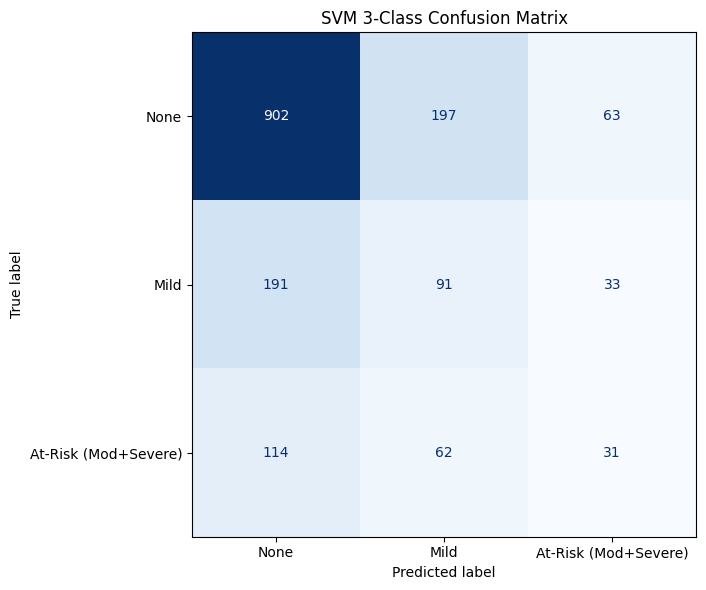

In [8]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=CLASSES_3),
    display_labels=CLASS_NAMES_3
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM 3-Class Confusion Matrix')
plt.tight_layout()
plt.savefig('svm_3class_confusion.png', dpi=150)
plt.show()

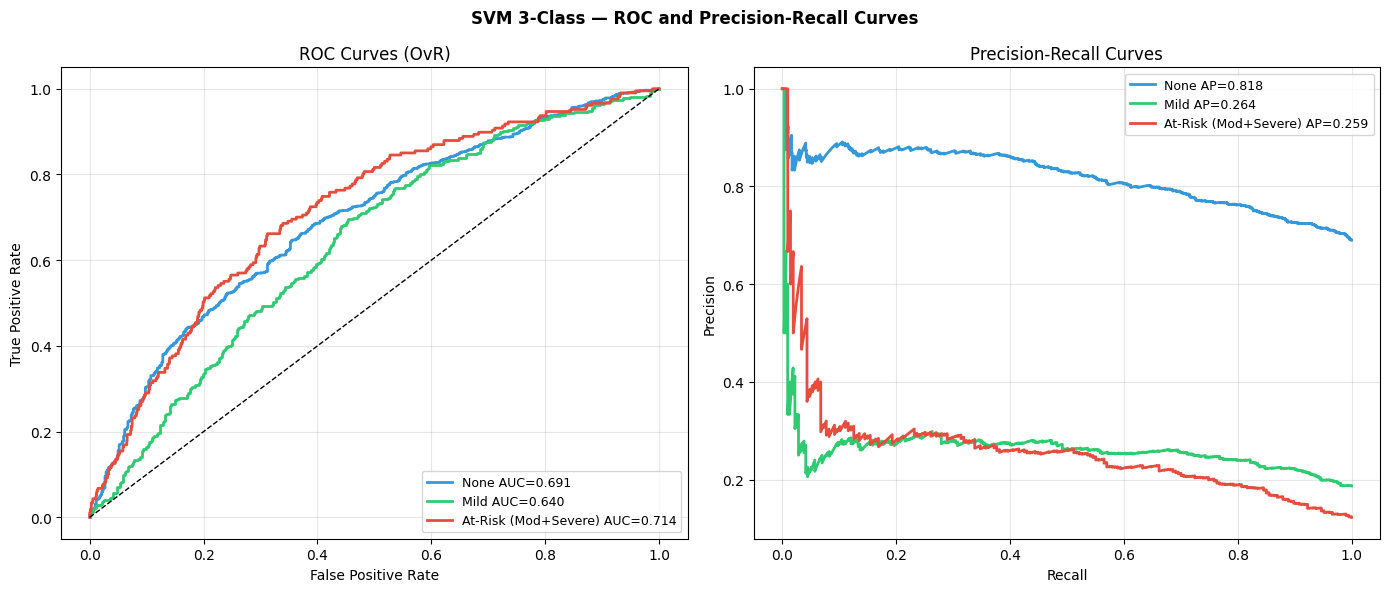

In [9]:
# ROC + Precision-Recall curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors3 = ['#3498DB','#2ECC71','#E74C3C']

# ROC
for i, (color, name) in enumerate(zip(colors3, CLASS_NAMES_3)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} AUC={auc(fpr,tpr):.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (OvR)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall
for i, (color, name) in enumerate(zip(colors3, CLASS_NAMES_3)):
    prec, rec_vals, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
    ap = average_precision_score(y_bin[:,i], y_prob[:,i])
    axes[1].plot(rec_vals, prec, color=color, lw=2,
                 label=f'{name} AP={ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('SVM 3-Class — ROC and Precision-Recall Curves',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_3class_curves.png', dpi=150)
plt.show()

---
## Section 4 — Comparison: 4-class vs 3-class

In [10]:
from sklearn.metrics import recall_score as rec

recall_3 = rec(y_test, y_pred, labels=CLASSES_3, average=None, zero_division=0)

print('Per-class recall - 3-class:')
for cls, name, r in zip(CLASSES_3, CLASS_NAMES_3, recall_3):
    print(f'  {name}: {r:.4f}')

print('\n4-class SVM reference:')
print('  None:     0.6308')
print('  Mild:     0.4589')
print('  Moderate: 0.2063')
print('  Severe:   0.0588')

print(f'\nAt-Risk recall (3-class) = {recall_3[2]:.4f}')
print('At-Risk = Moderate + Severe combined')
print('If At-Risk recall > 0.20 -> merging helped detect clinically relevant cases')

Per-class recall - 3-class:
  None: 0.7762
  Mild: 0.2889
  At-Risk (Mod+Severe): 0.1498

4-class SVM reference:
  None:     0.6308
  Mild:     0.4589
  Moderate: 0.2063
  Severe:   0.0588

At-Risk recall (3-class) = 0.1498
At-Risk = Moderate + Severe combined
If At-Risk recall > 0.20 -> merging helped detect clinically relevant cases


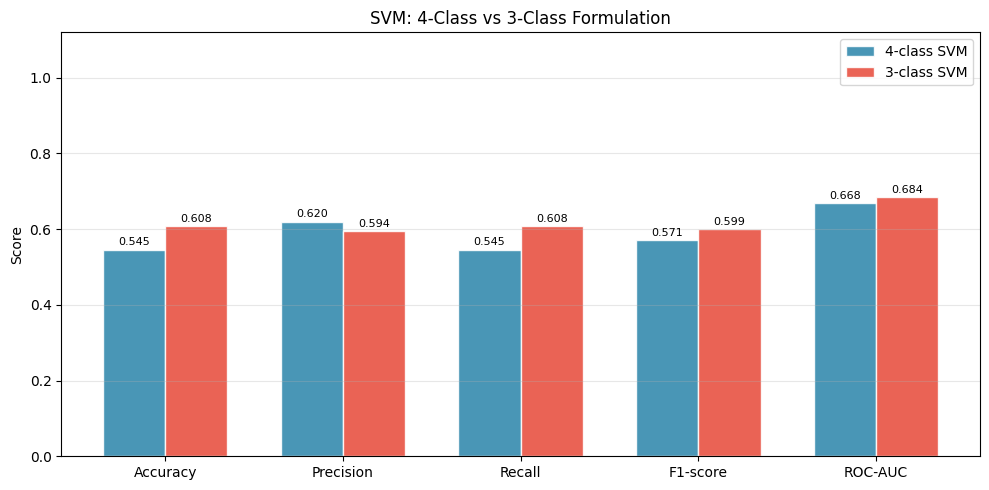

In [11]:
# Side-by-side comparison chart
metrics_labels = ['Accuracy','Precision','Recall','F1-score','ROC-AUC']
vals_4class = [0.5451, 0.6202, 0.5451, 0.5710, 0.6679]
vals_3class = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='weighted', zero_division=0),
    recall_score(y_test, y_pred, average='weighted', zero_division=0),
    f1_score(y_test, y_pred, average='weighted', zero_division=0),
    roc_auc
]

x = np.arange(len(metrics_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w/2, vals_4class, w, label='4-class SVM',
       color='#2E86AB', alpha=0.87, edgecolor='white')
ax.bar(x+w/2, vals_3class, w, label='3-class SVM',
       color='#E74C3C', alpha=0.87, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('SVM: 4-Class vs 3-Class Formulation')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i,(v4,v3) in enumerate(zip(vals_4class, vals_3class)):
    ax.text(i-w/2, v4+0.012, f'{v4:.3f}', ha='center', fontsize=8)
    ax.text(i+w/2, v3+0.012, f'{v3:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('svm_4vs3class.png', dpi=150)
plt.show()

---
## Section 5 — Feature Importance (if Linear kernel)

In [12]:
if best_svm.kernel == 'linear':
    coef_df = pd.DataFrame(
        best_svm.coef_,
        index=CLASS_NAMES_3,
        columns=feature_cols
    ).T
    mean_abs = coef_df.abs().mean(axis=1).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(mean_abs.index[:15], mean_abs.values[:15],
            color='#E74C3C', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean Absolute Weight')
    ax.set_title('Linear SVM 3-Class — Feature Importance')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('svm_3class_feature_importance.png', dpi=150)
    plt.show()
    print('Top 10 features:')
    print(mean_abs.head(10).round(4).to_string())
else:
    print(f'Best model uses {best_svm.kernel} kernel.')
    print('Feature weights not available for RBF. Use SHAP for importance.')

Best model uses rbf kernel.
Feature weights not available for RBF. Use SHAP for importance.


---
## Section 6 — Summary

In [13]:
print('=' * 60)
print('SVM 3-CLASS SUMMARY')
print('=' * 60)
print(f'Best params: {grid_search.best_params_}')
print(f'\nOverall metrics:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  F1-score:  {f1_score(y_test, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print(f'\nPer-class recall:')
for cls, name, r in zip(CLASSES_3, CLASS_NAMES_3, recall_3):
    print(f'  {name}: {r:.4f}')
print(f'\nAt-Risk recall: {recall_3[2]:.4f} vs 4-class Severe recall: 0.0588')
if recall_3[2] > 0.10:
    print('-> Merging improved detection of clinically significant cases.')
    print('   At-Risk class has 1033 training samples vs 69 Severe in 4-class.')
    print('   Clinical justification: both Moderate and Severe need intervention.')
else:
    print('-> Merging provided limited improvement.')
    print('   Core class overlap remains. Ensemble methods expected to outperform.')

SVM 3-CLASS SUMMARY
Best params: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}

Overall metrics:
  Accuracy:  0.6081
  Precision: 0.5943
  Recall:    0.6081
  F1-score:  0.5995
  ROC-AUC:   0.6843

Per-class recall:
  None: 0.7762
  Mild: 0.2889
  At-Risk (Mod+Severe): 0.1498

At-Risk recall: 0.1498 vs 4-class Severe recall: 0.0588
-> Merging improved detection of clinically significant cases.
   At-Risk class has 1033 training samples vs 69 Severe in 4-class.
   Clinical justification: both Moderate and Severe need intervention.
